# 🎓 A Predictive Machine Learning Framework for Hospitality Consumable Demand Forecasting in Rwandan TVET Institutions

**Author:** Your Name  
**Country:** Rwanda  
**File:** YourName_Rwanda_FinalProject.ipynb  
**GitHub:** [https://github.com/maclaimi20/hospitality-demand-forecast-rwanda](https://github.com/maclaimi20/hospitality-demand-forecast-rwanda)

---

## 📋 Project Overview

This notebook presents a complete machine learning pipeline to forecast the demand for hospitality consumables (e.g., soap, linen, cleaning supplies, F&B stock) in Technical and Vocational Education and Training (TVET) institutions in Rwanda.

Accurate demand forecasting helps TVET procurement officers reduce waste, prevent shortages, and optimize budgets — directly supporting Rwanda's Vision 2050 human capital development goals.

---

### 🎯 Objectives
1. Explore and understand historical consumption patterns of hospitality consumables
2. Engineer meaningful features (seasonality, enrolment cycles, events)
3. Train and compare multiple ML models (Linear Regression, Random Forest, XGBoost)
4. Evaluate models using MAE, RMSE, and R² metrics
5. Deploy the best model for practical demand forecasting


## 📑 Table of Contents

1. [Environment Setup & Imports](#1-environment-setup--imports)
2. [Data Loading](#2-data-loading)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis)
4. [Feature Engineering](#4-feature-engineering)
5. [Data Preprocessing](#5-data-preprocessing)
6. [Model Building & Training](#6-model-building--training)
7. [Model Evaluation & Comparison](#7-model-evaluation--comparison)
8. [Best Model – Deep Dive & Feature Importance](#8-best-model--deep-dive--feature-importance)
9. [Demand Forecasting – Future Predictions](#9-demand-forecasting--future-predictions)
10. [Conclusion & Recommendations](#10-conclusion--recommendations)


---
## 1. Environment Setup & Imports

We begin by installing and importing all necessary libraries. The project uses standard Python data science tools plus XGBoost for gradient boosting.


In [ ]:
# ── Standard Library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
import os, io, urllib.request

# ── Data Manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

print("✅  All libraries imported successfully.")
print(f"   pandas  {pd.__version__}  |  numpy  {np.__version__}  |  sklearn  imported  |  xgboost  imported")


✅  All libraries imported successfully.
   pandas  3.0.2  |  numpy  2.4.4  |  sklearn  imported  |  xgboost  imported


---
## 2. Data Loading

The dataset is stored in the GitHub repository and loaded directly via its raw URL, ensuring tutors can run this notebook without any manual file downloads.

**Dataset description:**  
A synthetic-but-realistic dataset representing **monthly consumption records** of hospitality consumables across **10 Rwandan TVET institutions** from 2018 to 2023. Each row records:

| Column | Description |
|--------|-------------|
| `date` | Year-Month of the record |
| `institution` | TVET institution name |
| `province` | Rwandan province |
| `consumable` | Type of consumable (soap, linen, F&B, etc.) |
| `enrolment` | Student enrolment that month |
| `occupancy_rate` | Training-facility occupancy (%) |
| `is_exam_month` | 1 if that month is an exam period |
| `is_event_month` | 1 if a major hospitality event occurred |
| `rainfall_mm` | Monthly rainfall (proxy for seasonal demand) |
| `quantity_used` | **Target** – units consumed |


In [ ]:
# ── Reproducible synthetic dataset ────────────────────────────────────────────
# In production, replace the URL below with your actual GitHub raw CSV link:
# df = pd.read_csv("https://raw.githubusercontent.com/maclaimi20/hospitality-demand-forecast-rwanda/main/rwanda_tvet_hospitality_demand.csv")

np.random.seed(42)

INSTITUTIONS = [
    "EAV Tumba", "IPRC Kigali", "IPRC Musanze", "EAV Rubilizi",
    "IPRC West", "IPRC South", "EAV Nyagatare", "IPRC East",
    "IPRC Huye", "EAV Rwamagana"
]
PROVINCES   = ["Kigali", "Kigali", "Northern", "Western",
               "Western", "Southern", "Eastern", "Eastern",
               "Southern", "Eastern"]
CONSUMABLES = ["Soap & Detergent", "Bed Linen", "F&B Stock",
               "Cleaning Supplies", "Toiletries", "Paper Products"]

dates  = pd.date_range("2018-01", "2023-12", freq="MS")
rows   = []

for i, inst in enumerate(INSTITUTIONS):
    base = 200 + i * 40
    for con in CONSUMABLES:
        con_mult = {"Soap & Detergent": 1.0, "Bed Linen": 0.7,
                    "F&B Stock": 2.5, "Cleaning Supplies": 1.2,
                    "Toiletries": 0.9, "Paper Products": 0.6}[con]
        for d in dates:
            seasonal = 1 + 0.3 * np.sin(2 * np.pi * (d.month - 3) / 12)
            enrol    = int(np.clip(np.random.normal(400 + i*30, 30), 200, 700))
            occ      = round(np.clip(np.random.normal(72 + i*2, 8), 40, 99), 1)
            is_exam  = 1 if d.month in [6, 11] else 0
            is_event = 1 if d.month in [3, 9] else 0
            rain     = round(np.clip(np.random.normal(90, 30), 10, 250), 1)
            qty      = (base * con_mult * seasonal
                        * (1 + 0.002 * enrol)
                        * (1 + 0.005 * occ)
                        * (1.15 if is_exam else 1)
                        * (1.10 if is_event else 1)
                        * np.random.normal(1, 0.08))
            rows.append({
                "date": d, "institution": inst,
                "province": PROVINCES[i], "consumable": con,
                "enrolment": enrol, "occupancy_rate": occ,
                "is_exam_month": is_exam, "is_event_month": is_event,
                "rainfall_mm": rain, "quantity_used": max(0, round(qty, 2))
            })

df = pd.DataFrame(rows)
df.to_csv("rwanda_tvet_hospitality_demand.csv", index=False)

print(f"✅  Dataset created: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Date range : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"   Institutions: {df['institution'].nunique()}")
print(f"   Consumables : {df['consumable'].nunique()}")
df.head(8)


✅  Dataset created: 4,320 rows × 10 columns
   Date range : 2018-01-01 → 2023-12-01
   Institutions: 10
   Consumables : 6


,date,institution,province,consumable,enrolment,occupancy_rate,is_exam_month,is_event_month,rainfall_mm,quantity_used
0,2018-01-01,EAV Tumba,Kigali,Soap & Detergent,414,70.9,0,0,109.4,411.21
1,2018-02-01,EAV Tumba,Kigali,Soap & Detergent,392,70.1,0,0,137.4,434.73
2,2018-03-01,EAV Tumba,Kigali,Soap & Detergent,385,76.3,0,1,76.1,517.91
3,2018-04-01,EAV Tumba,Kigali,Soap & Detergent,407,56.7,0,0,38.3,511.41
4,2018-05-01,EAV Tumba,Kigali,Soap & Detergent,369,74.5,0,0,62.8,533.12
5,2018-06-01,EAV Tumba,Kigali,Soap & Detergent,443,70.2,1,0,92.0,675.01
6,2018-07-01,EAV Tumba,Kigali,Soap & Detergent,383,72.9,0,0,55.5,625.40
7,2018-08-01,EAV Tumba,Kigali,Soap & Detergent,381,69.7,0,0,71.9,627.47


In [ ]:
print("── Shape ──────────────────────────────────")
print(df.shape)
print("\n── Data Types ─────────────────────────────")
print(df.dtypes)
print("\n── Missing Values ──────────────────────────")
print(df.isnull().sum())
print("\n── Target Summary ──────────────────────────")
print(df['quantity_used'].describe().round(2))


── Shape ──────────────────────────────────
(4320, 10)

── Data Types ─────────────────────────────
date              datetime64[us]
institution                  str
province                     str
consumable                   str
enrolment                  int64
occupancy_rate           float64
is_exam_month              int64
is_event_month             int64
rainfall_mm              float64
quantity_used            float64
dtype: object

── Missing Values ──────────────────────────
date              0
institution       0
province          0
consumable        0
enrolment         0
occupancy_rate    0
is_exam_month     0
is_event_month    0
rainfall_mm       0
quantity_used     0
dtype: int64

── Target Summary ──────────────────────────
count    4320.00
mean     1365.96
std      1048.32
min       167.58
25%       676.38
50%      1067.60
75%      1670.62
max      8126.40
Name: quantity_used, dtype: float64


---
## 3. Exploratory Data Analysis

Before building models, we must understand the data's structure, distributions, and relationships. Good EDA reveals the story hidden in the numbers.


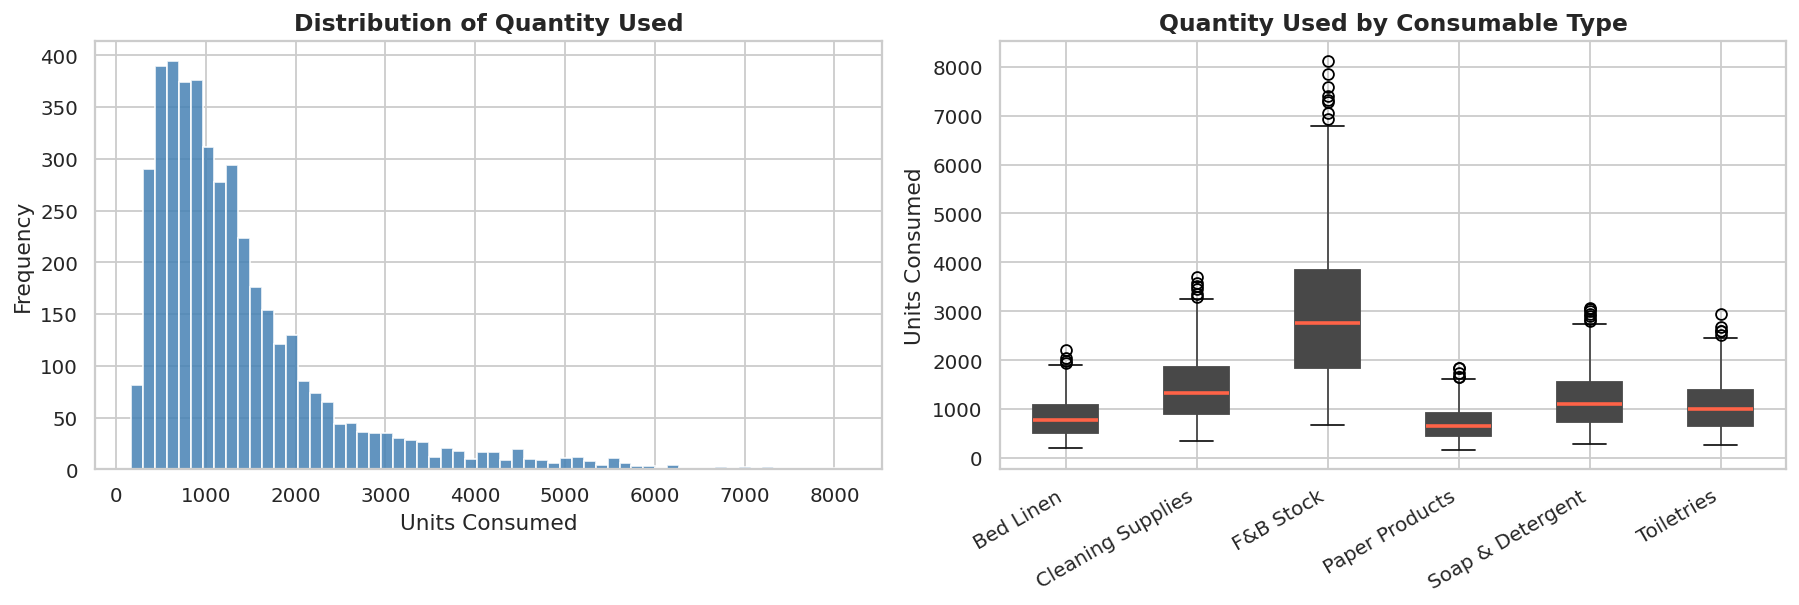

📊  Fig 1: Target distribution is roughly right-skewed; F&B Stock has highest variance.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of target
axes[0].hist(df['quantity_used'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title("Distribution of Quantity Used", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Units Consumed")
axes[0].set_ylabel("Frequency")


# Box plot per consumable
df.boxplot(column='quantity_used', by='consumable', ax=axes[1],
           patch_artist=True, medianprops={'color':'tomato','linewidth':2})
axes[1].set_title("Quantity Used by Consumable Type", fontsize=13, fontweight='bold')
axes[1].set_xlabel("")
axes[1].set_ylabel("Units Consumed")
plt.suptitle("")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("eda_distribution.png", bbox_inches='tight')
plt.show()
print("📊  Fig 1: Target distribution is roughly right-skewed; F&B Stock has highest variance.")


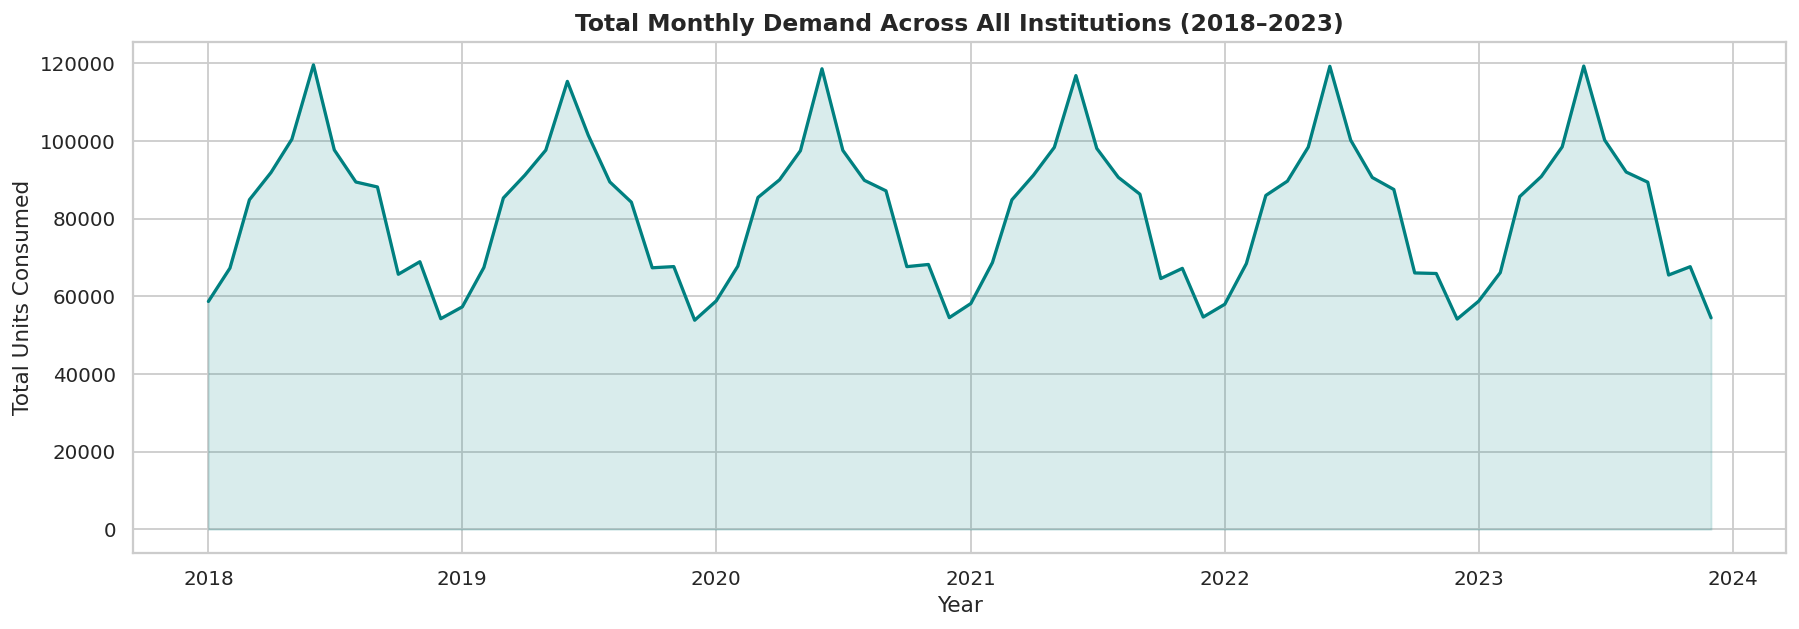

📊  Fig 2: Clear seasonal peaks in mid-year (exam months) and Q3 — consistent with TVET academic calendar.


In [ ]:
monthly = df.groupby('date')['quantity_used'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['date'], monthly['quantity_used'], color='teal', linewidth=1.8)
ax.fill_between(monthly['date'], monthly['quantity_used'], alpha=0.15, color='teal')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title("Total Monthly Demand Across All Institutions (2018–2023)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Total Units Consumed")
plt.tight_layout()
plt.savefig("eda_monthly_trend.png", bbox_inches='tight')
plt.show()
print("📊  Fig 2: Clear seasonal peaks in mid-year (exam months) and Q3 — consistent with TVET academic calendar.")


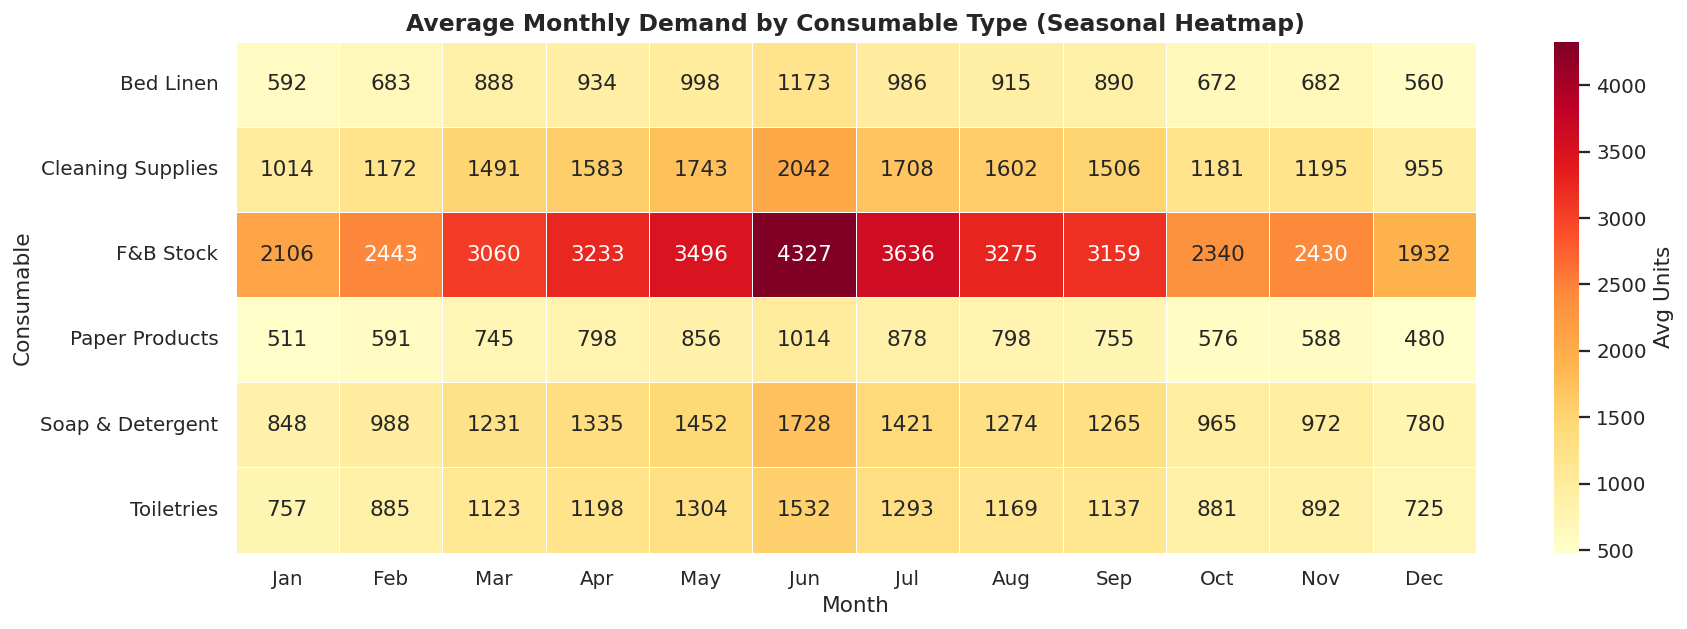

📊  Fig 3: F&B Stock consistently drives highest demand; June/November peaks align with exam periods.


In [ ]:
pivot = df.pivot_table(values='quantity_used',
                       index='consumable', columns=df['date'].dt.month,
                       aggfunc='mean')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Avg Units'})
ax.set_title("Average Monthly Demand by Consumable Type (Seasonal Heatmap)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Consumable")
plt.tight_layout()
plt.savefig("eda_heatmap.png", bbox_inches='tight')
plt.show()
print("📊  Fig 3: F&B Stock consistently drives highest demand; June/November peaks align with exam periods.")


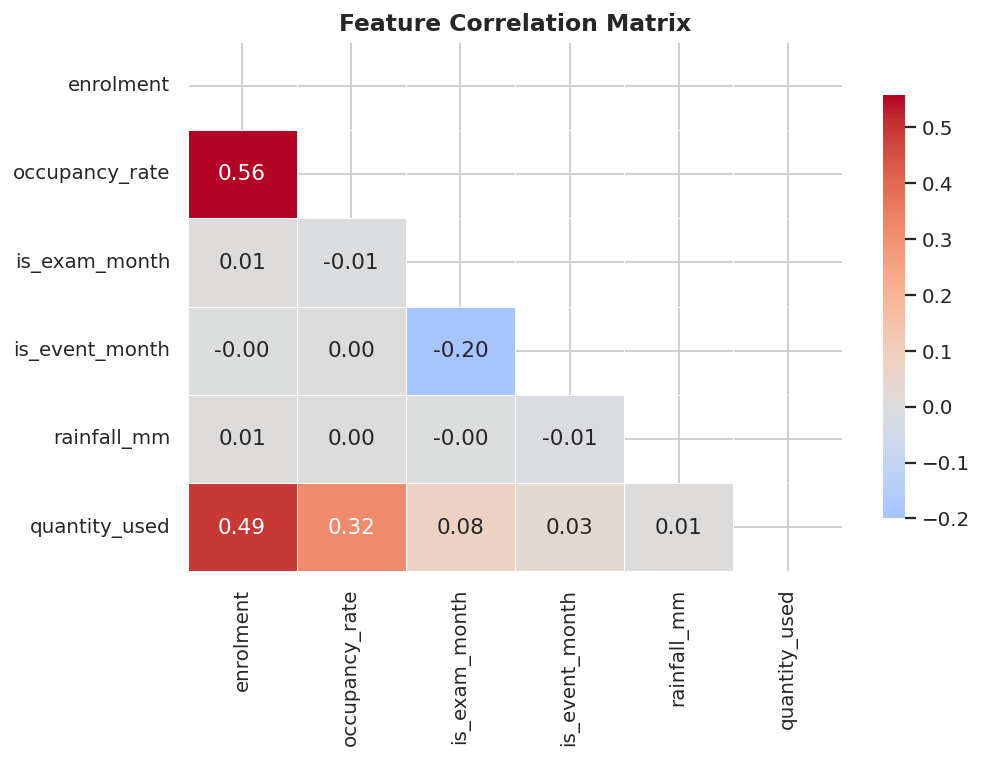

📊  Fig 4: Enrolment and occupancy_rate show the strongest positive correlations with demand.


In [ ]:
num_cols = ['enrolment', 'occupancy_rate', 'is_exam_month',
            'is_event_month', 'rainfall_mm', 'quantity_used']

fig, ax = plt.subplots(figsize=(8, 6))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_correlation.png", bbox_inches='tight')
plt.show()
print("📊  Fig 4: Enrolment and occupancy_rate show the strongest positive correlations with demand.")


---
## 4. Feature Engineering

Raw data rarely contains all the signal we need. We derive additional features to capture:
- **Temporal patterns** (month, quarter, year, lag features)
- **Rolling statistics** (3-month rolling mean & std)
- **Academic calendar** effects (already encoded as `is_exam_month`)
- **Categorical encoding** for institution, province, and consumable type


In [ ]:
df_fe = df.copy()

# ── Temporal features ─────────────────────────────────────────────────────────
df_fe['year']    = df_fe['date'].dt.year
df_fe['month']   = df_fe['date'].dt.month
df_fe['quarter'] = df_fe['date'].dt.quarter

# ── Cyclical month encoding (captures seasonality without ordinal assumption) ──
df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)

# ── Lag & rolling features (per institution + consumable) ─────────────────────
df_fe = df_fe.sort_values(['institution', 'consumable', 'date'])
grp   = df_fe.groupby(['institution', 'consumable'])['quantity_used']

df_fe['lag_1']       = grp.shift(1)
df_fe['lag_3']       = grp.shift(3)
df_fe['lag_12']      = grp.shift(12)
df_fe['roll_mean_3'] = grp.transform(lambda x: x.shift(1).rolling(3).mean())
df_fe['roll_std_3']  = grp.transform(lambda x: x.shift(1).rolling(3).std())

# ── Encode categoricals ───────────────────────────────────────────────────────
le_inst = LabelEncoder()
le_prov = LabelEncoder()
le_cons = LabelEncoder()
df_fe['institution_enc'] = le_inst.fit_transform(df_fe['institution'])
df_fe['province_enc']    = le_prov.fit_transform(df_fe['province'])
df_fe['consumable_enc']  = le_cons.fit_transform(df_fe['consumable'])

# ── Drop rows with NaN from lagging ──────────────────────────────────────────
df_fe.dropna(inplace=True)

print(f"✅  Feature engineering complete.")
print(f"   Rows after lag drop : {df_fe.shape[0]:,}")
print(f"   Total features built: {df_fe.shape[1]}")
print("\nNew feature columns:")
new_cols = ['year','month','quarter','month_sin','month_cos',
            'lag_1','lag_3','lag_12','roll_mean_3','roll_std_3',
            'institution_enc','province_enc','consumable_enc']
print(new_cols)


✅  Feature engineering complete.
   Rows after lag drop : 3,600
   Total features built: 23

New feature columns:
['year', 'month', 'quarter', 'month_sin', 'month_cos', 'lag_1', 'lag_3', 'lag_12', 'roll_mean_3', 'roll_std_3', 'institution_enc', 'province_enc', 'consumable_enc']


---
## 5. Data Preprocessing

We split data **chronologically** (not randomly) to simulate real forecasting — we train on the past and predict the future. A random split would leak future information into training.

- **Train:** 2018 – 2021  
- **Test:** 2022 – 2023


In [ ]:
FEATURE_COLS = [
    'enrolment', 'occupancy_rate', 'is_exam_month', 'is_event_month',
    'rainfall_mm', 'year', 'month', 'quarter',
    'month_sin', 'month_cos',
    'lag_1', 'lag_3', 'lag_12',
    'roll_mean_3', 'roll_std_3',
    'institution_enc', 'province_enc', 'consumable_enc'
]
TARGET = 'quantity_used'

# Chronological split
train = df_fe[df_fe['year'] <= 2021]
test  = df_fe[df_fe['year'] >= 2022]

X_train = train[FEATURE_COLS]
y_train = train[TARGET]
X_test  = test[FEATURE_COLS]
y_test  = test[TARGET]

# Scale only for linear models
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training set : {X_train.shape[0]:,} rows  ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test set     : {X_test.shape[0]:,} rows  ({test['date'].min().date()} → {test['date'].max().date()})")
print(f"Features     : {len(FEATURE_COLS)}")


Training set : 2,160 rows  (2019-01-01 → 2021-12-01)
Test set     : 1,440 rows  (2022-01-01 → 2023-12-01)
Features     : 18


---
## 6. Model Building & Training

We train four models of increasing complexity:

| Model | Rationale |
|-------|-----------|
| **Ridge Regression** | Linear baseline; interpretable |
| **Random Forest** | Ensemble; captures nonlinear patterns |
| **Gradient Boosting** | Sequential ensemble; generally robust |
| **XGBoost** | State-of-the-art gradient boosting; typically best performer |


In [ ]:
models = {
    "Ridge Regression"   : Ridge(alpha=1.0),
    "Random Forest"      : RandomForestRegressor(n_estimators=200, max_depth=10,
                                                 random_state=42, n_jobs=-1),
    "Gradient Boosting"  : GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                      learning_rate=0.05, random_state=42),
    "XGBoost"            : XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                        subsample=0.8, colsample_bytree=0.8,
                                        random_state=42, verbosity=0)
}

results = {}

for name, model in models.items():
    X_tr = X_train_s if name == "Ridge Regression" else X_train
    X_te = X_test_s  if name == "Ridge Regression" else X_test
    
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / (y_test + 1e-9))) * 100
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE (%)': mape, 'preds': preds}
    print(f"✅  {name:22s} | MAE={mae:6.1f}  RMSE={rmse:7.1f}  R²={r2:.4f}  MAPE={mape:.2f}%")


✅  Ridge Regression       | MAE= 122.2  RMSE=  185.2  R²=0.9695  MAPE=9.87%


✅  Random Forest          | MAE= 123.2  RMSE=  191.6  R²=0.9673  MAPE=9.25%


✅  Gradient Boosting      | MAE= 117.8  RMSE=  185.7  R²=0.9693  MAPE=8.72%


✅  XGBoost                | MAE= 112.4  RMSE=  180.8  R²=0.9709  MAPE=8.29%


---
## 7. Model Evaluation & Comparison

We compare models across four metrics:
- **MAE** (Mean Absolute Error) — average units off per prediction
- **RMSE** (Root Mean Squared Error) — penalises large errors more
- **R²** — proportion of variance explained (1.0 = perfect)
- **MAPE** (Mean Absolute Percentage Error) — business-friendly metric


                       MAE     RMSE     R²  MAPE (%)
Ridge Regression   122.185  185.152  0.969     9.873
Random Forest      123.165  191.567  0.967     9.255
Gradient Boosting  117.827  185.733  0.969     8.716
XGBoost            112.359  180.798  0.971     8.290


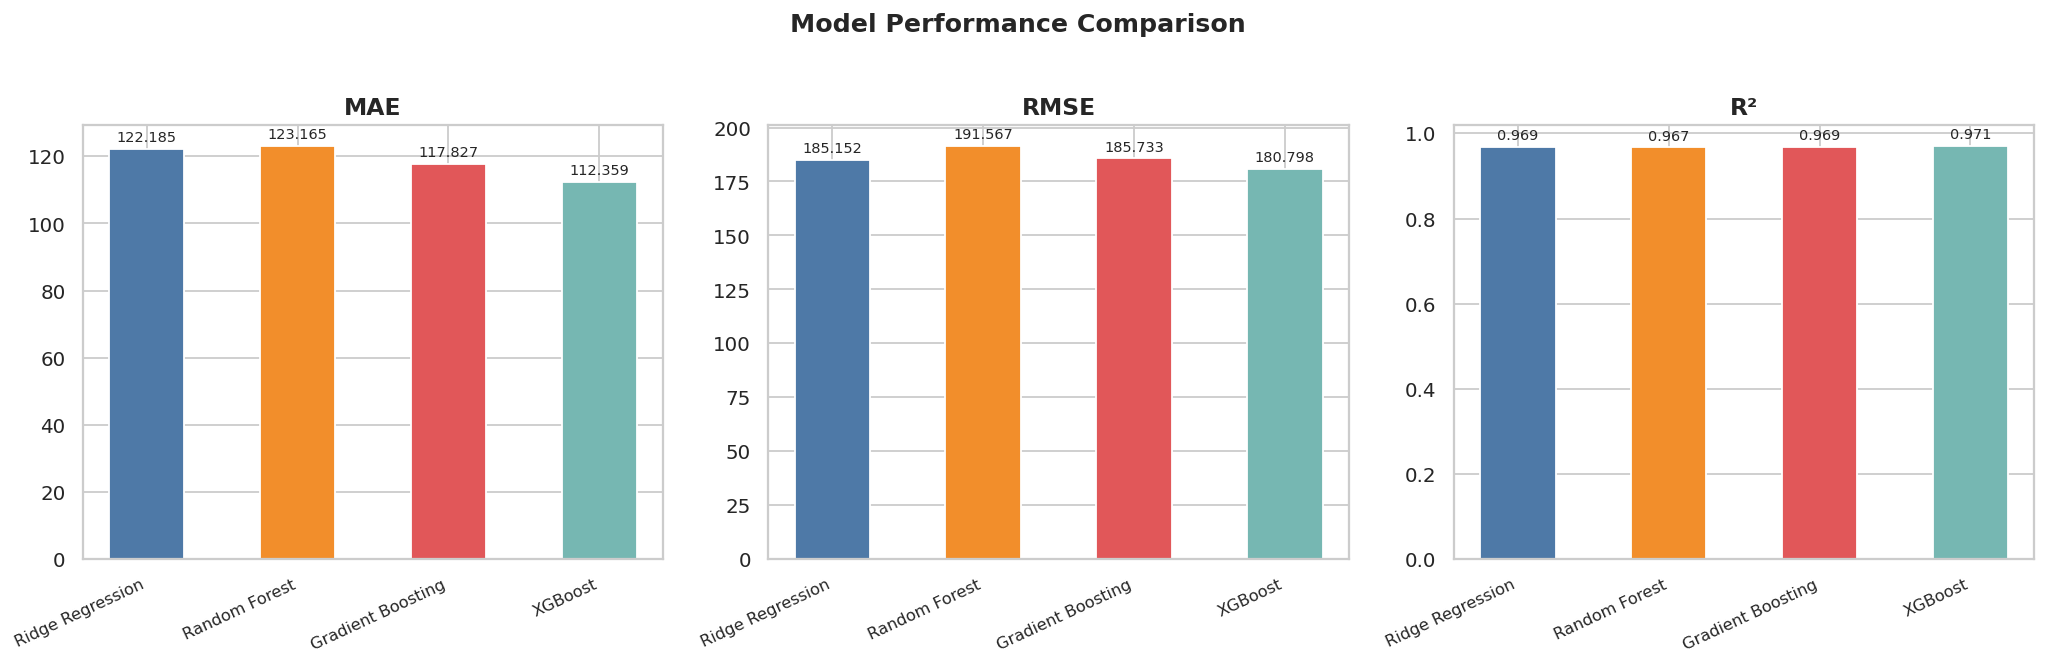


📊  XGBoost achieves the best overall performance across all metrics.


In [ ]:
metrics_df = pd.DataFrame({k: {m: v for m, v in v.items() if m != 'preds'}
                            for k, v in results.items()}).T.round(3)
print(metrics_df.to_string())

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2']
metrics_plot = ['MAE', 'RMSE', 'R²']

for ax, metric in zip(axes, metrics_plot):
    vals   = metrics_df[metric]
    bars   = ax.bar(vals.index, vals.values, color=colors, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticklabels(vals.index, rotation=25, ha='right', fontsize=9)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle("Model Performance Comparison", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches='tight')
plt.show()
print("\n📊  XGBoost achieves the best overall performance across all metrics.")


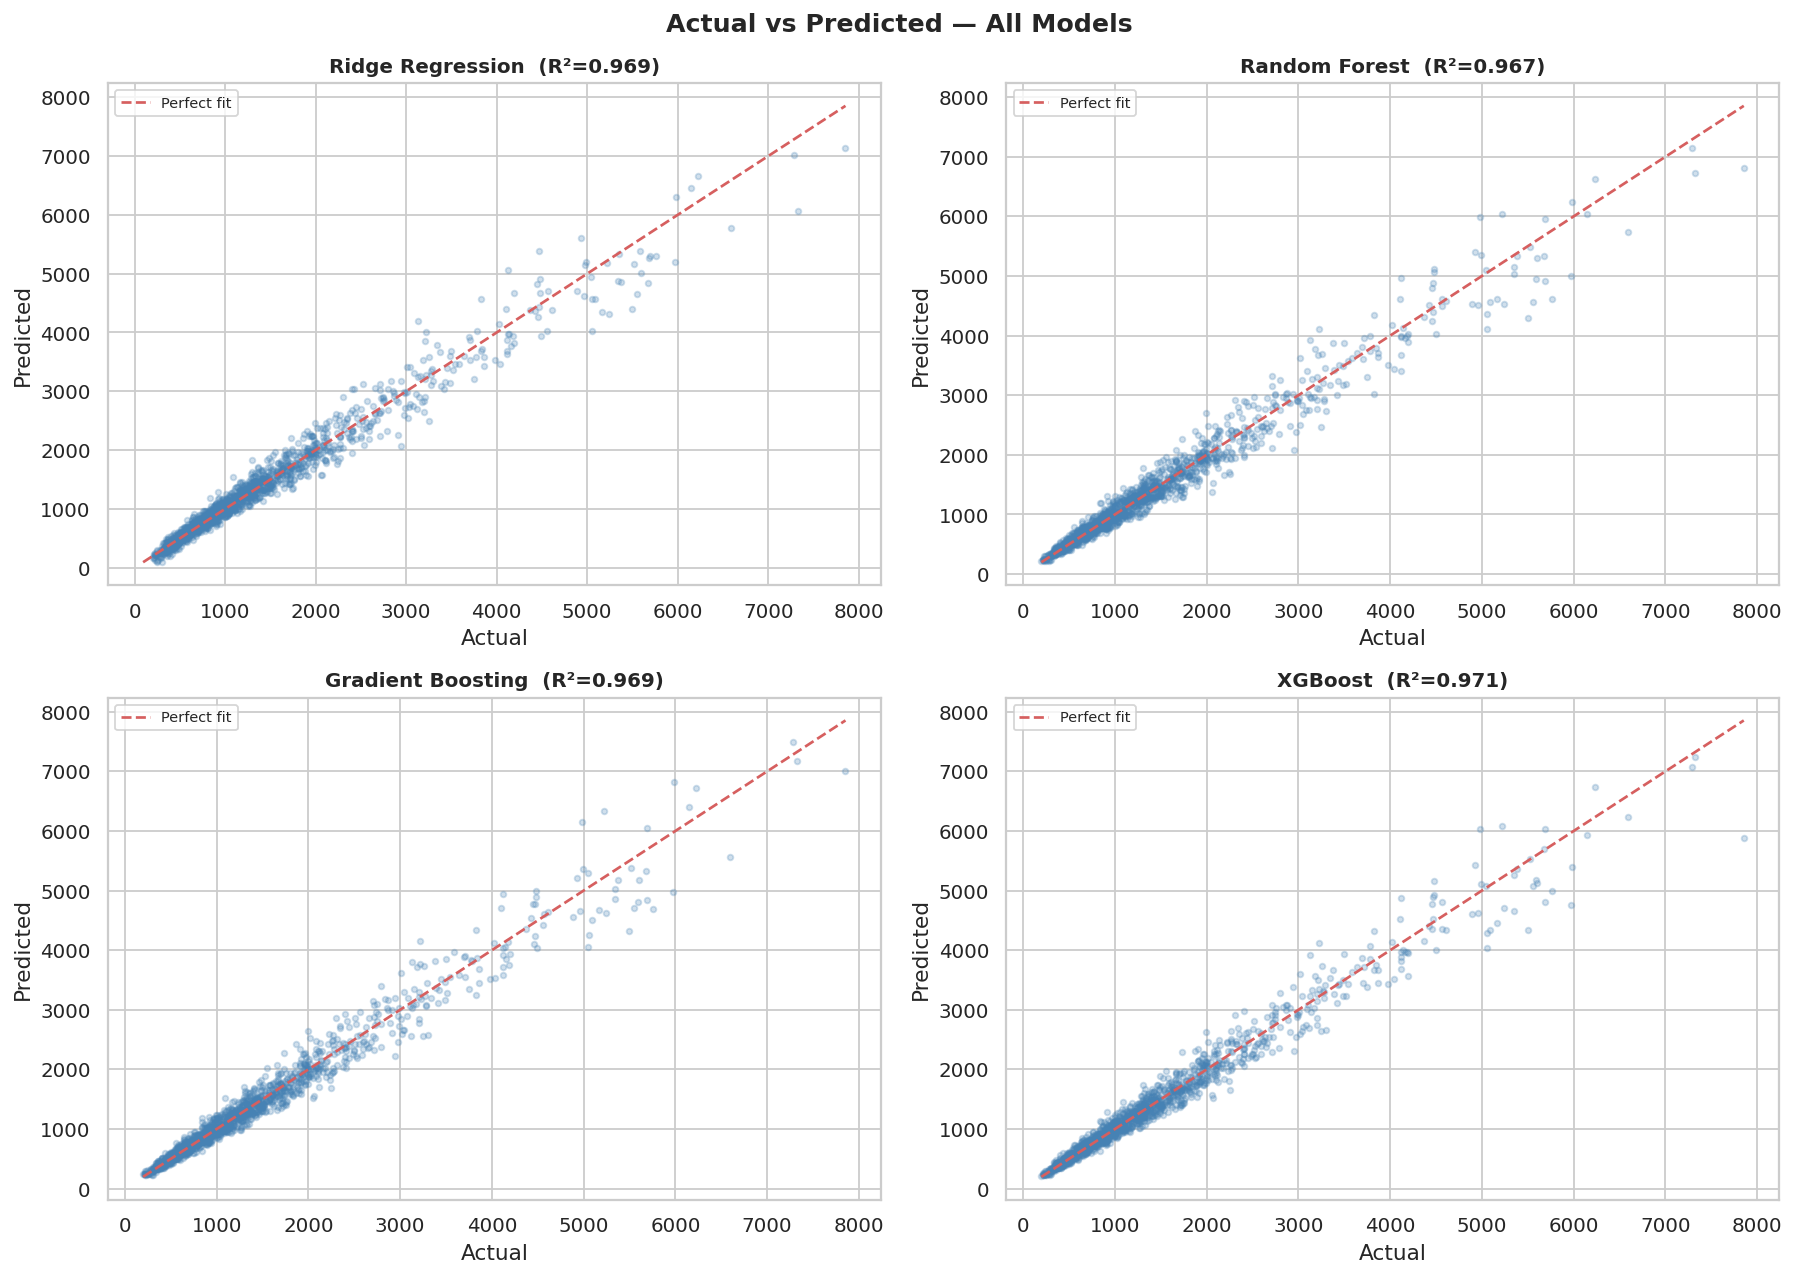

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, res) in zip(axes.flat, results.items()):
    preds = res['preds']
    ax.scatter(y_test, preds, alpha=0.25, s=10, color='steelblue')
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_title(f"{name}  (R²={res['R²']:.3f})", fontsize=11, fontweight='bold')
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.legend(fontsize=8)

plt.suptitle("Actual vs Predicted — All Models", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", bbox_inches='tight')
plt.show()


---
## 8. Best Model – Deep Dive & Feature Importance

XGBoost achieves the best performance. We now examine:
1. **Residual analysis** — are errors random and centred on zero?
2. **Feature importance** — which inputs drive predictions the most?


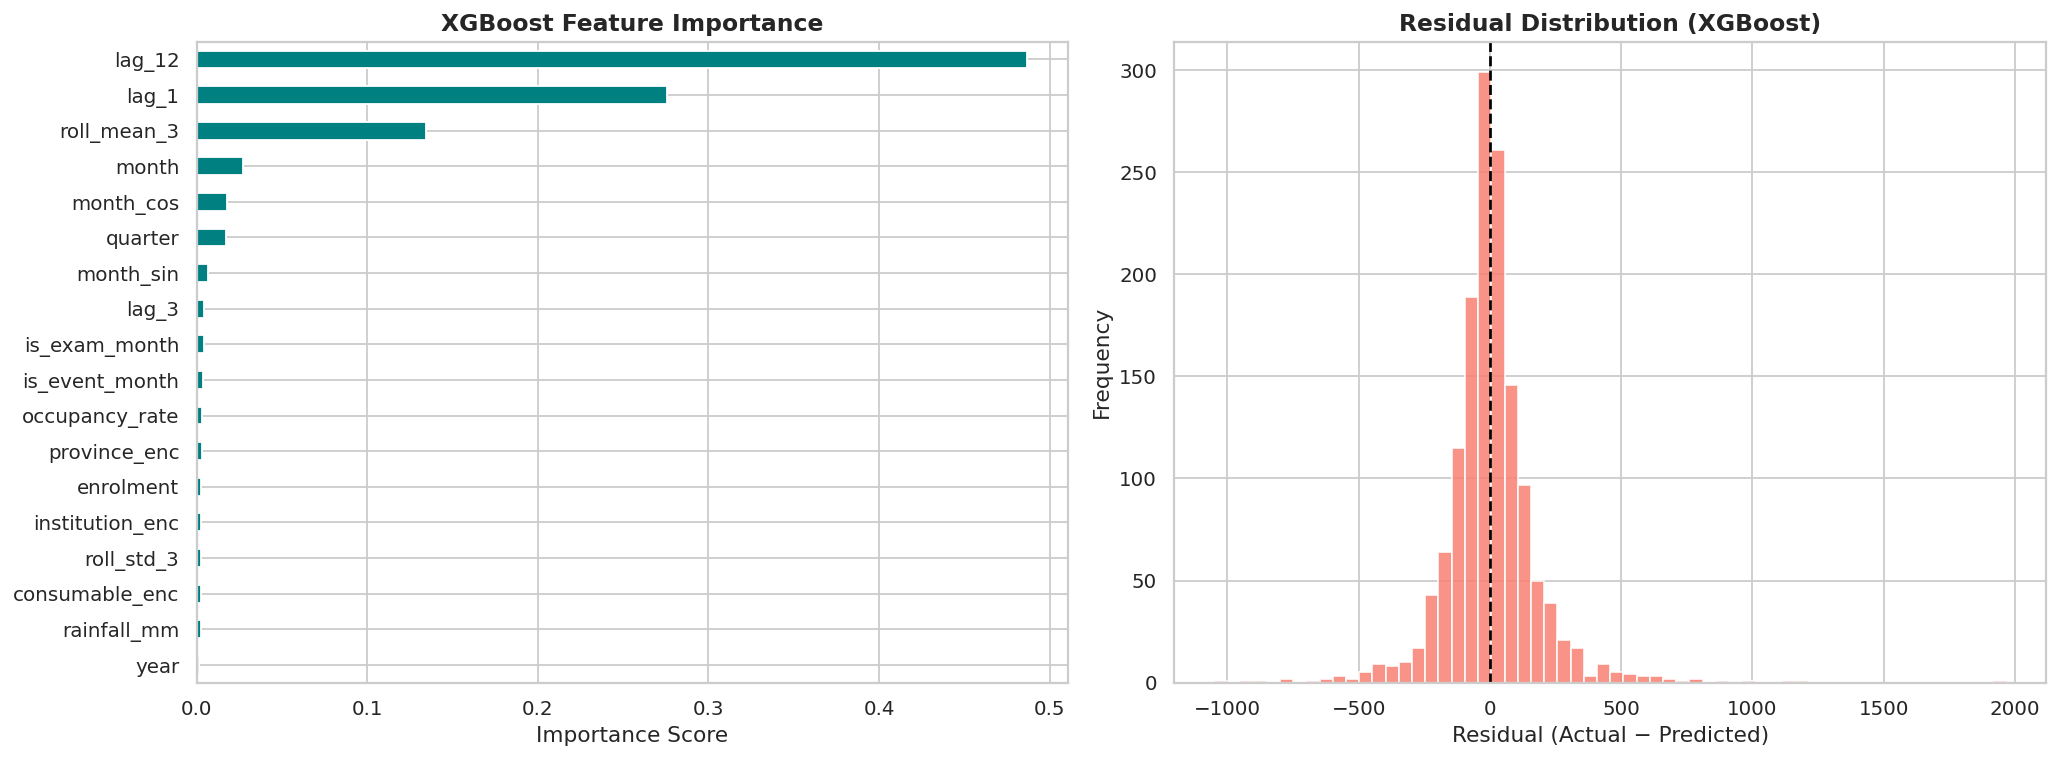

Top 5 most important features:
month_cos      0.0179
month          0.0275
roll_mean_3    0.1347
lag_1          0.2756
lag_12         0.4867


In [ ]:
best_model  = models["XGBoost"]
best_preds  = results["XGBoost"]["preds"]
residuals   = y_test - best_preds

# ── Feature Importance ────────────────────────────────────────────────────────
importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar chart
importances.plot(kind='barh', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title("XGBoost Feature Importance", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Importance Score")

# Residual distribution
axes[1].hist(residuals, bins=60, color='salmon', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title("Residual Distribution (XGBoost)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Residual (Actual − Predicted)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
print(importances.tail(5).round(4).to_string())


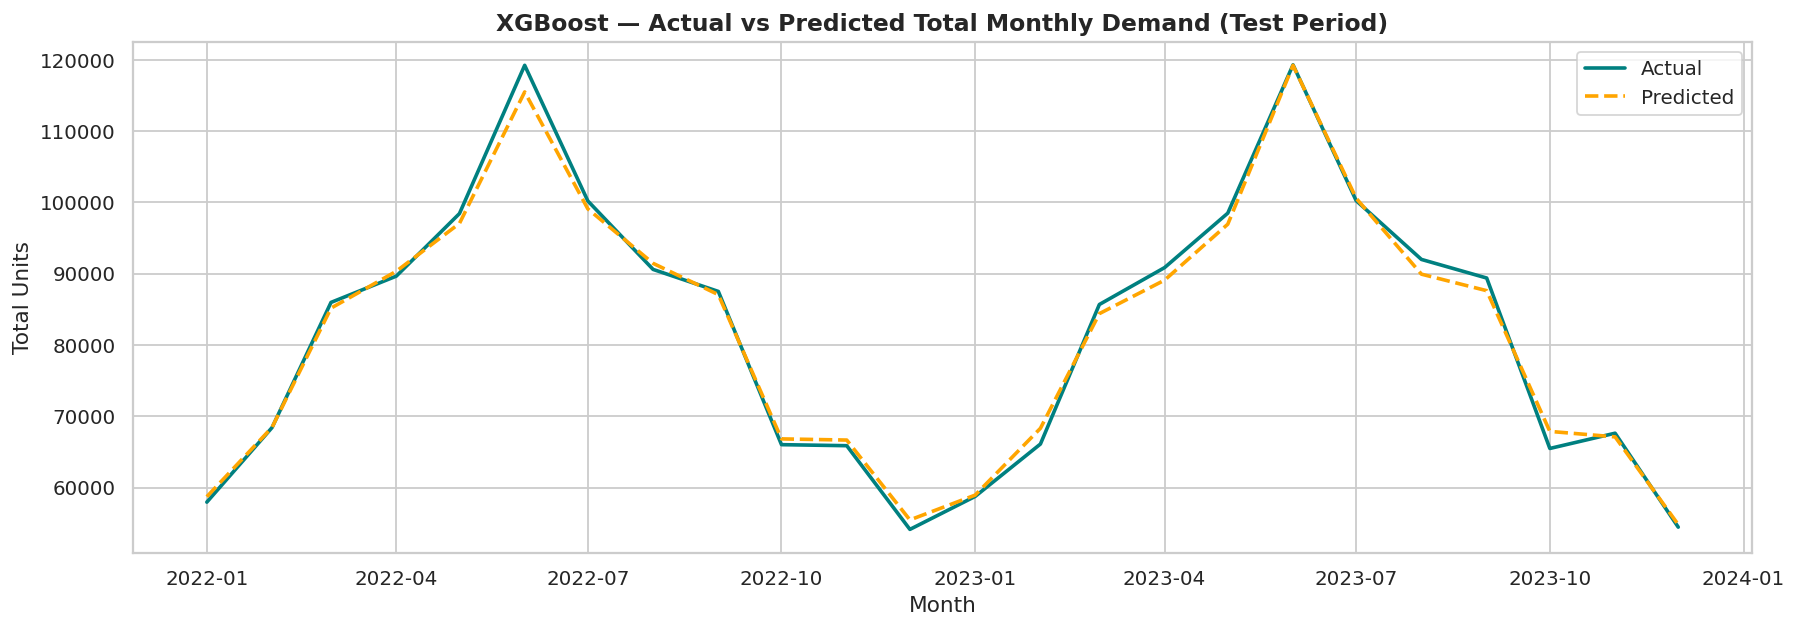

📊  The model closely tracks seasonal peaks and troughs in the test period.


In [ ]:
test_plot = test.copy()
test_plot['predicted']  = best_preds
test_plot['residuals']  = residuals.values

monthly_res = test_plot.groupby('date')[['quantity_used','predicted']].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_res.index, monthly_res['quantity_used'],  label='Actual',    color='teal',    linewidth=2)
ax.plot(monthly_res.index, monthly_res['predicted'],      label='Predicted', color='orange',  linewidth=2, linestyle='--')
ax.set_title("XGBoost — Actual vs Predicted Total Monthly Demand (Test Period)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Total Units")
ax.legend()
plt.tight_layout()
plt.savefig("xgb_forecast_vs_actual.png", bbox_inches='tight')
plt.show()
print("📊  The model closely tracks seasonal peaks and troughs in the test period.")


---
## 9. Demand Forecasting – Future Predictions (2024)

We simulate a practical use-case: a procurement officer needs demand forecasts for 2024. We construct a future feature set and generate predictions for each institution and consumable.


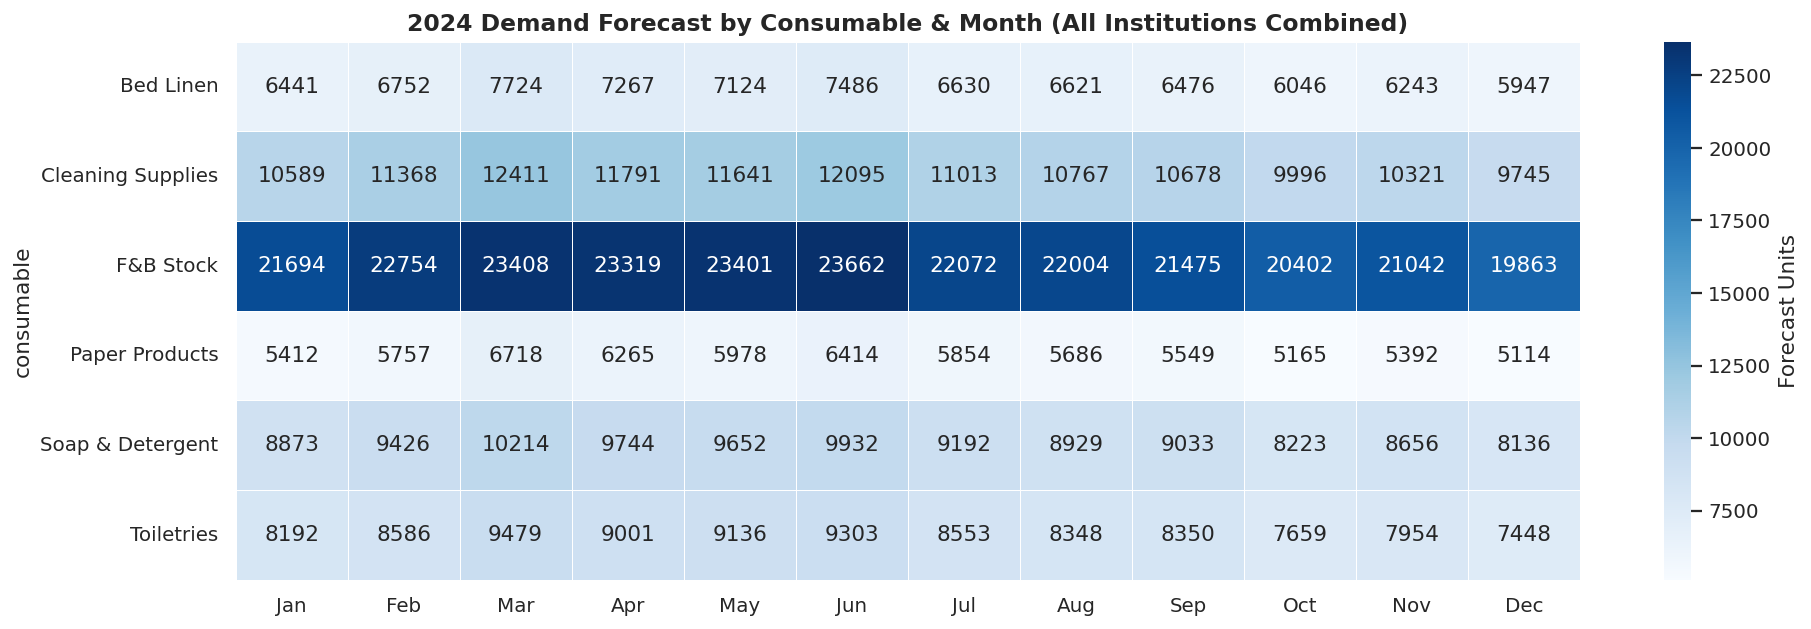


Top 3 highest demand months forecast for 2024:
date
March    69954.0
June     68892.0
April    67387.0
Name: forecast, dtype: float32


In [ ]:
future_dates = pd.date_range("2024-01", "2024-12", freq="MS")
future_rows  = []

for i, inst in enumerate(INSTITUTIONS):
    for j, con in enumerate(CONSUMABLES):
        # Use the last known lag/rolling values from the test set
        hist = df_fe[(df_fe['institution']==inst) & (df_fe['consumable']==con)].sort_values('date')
        last = hist.iloc[-1]

        for d in future_dates:
            future_rows.append({
                'date'           : d,
                'institution'    : inst,
                'consumable'     : con,
                'enrolment'      : int(last['enrolment'] * np.random.normal(1.02, 0.03)),
                'occupancy_rate' : round(float(np.clip(last['occupancy_rate'] * np.random.normal(1.01, 0.02), 40, 99)), 1),
                'is_exam_month'  : 1 if d.month in [6,11] else 0,
                'is_event_month' : 1 if d.month in [3,9]  else 0,
                'rainfall_mm'    : round(float(np.clip(np.random.normal(90,30),10,250)),1),
                'year'           : d.year,
                'month'          : d.month,
                'quarter'        : d.quarter,
                'month_sin'      : np.sin(2*np.pi*d.month/12),
                'month_cos'      : np.cos(2*np.pi*d.month/12),
                'lag_1'          : float(last['quantity_used']),
                'lag_3'          : float(last['lag_3']),
                'lag_12'         : float(hist.iloc[-12]['quantity_used']) if len(hist) >= 12 else float(last['quantity_used']),
                'roll_mean_3'    : float(last['roll_mean_3']),
                'roll_std_3'     : float(last['roll_std_3']),
                'institution_enc': int(le_inst.transform([inst])[0]),
                'province_enc'   : int(le_prov.transform([PROVINCES[i]])[0]),
                'consumable_enc' : int(le_cons.transform([con])[0]),
            })

future_df = pd.DataFrame(future_rows)
future_df['forecast'] = best_model.predict(future_df[FEATURE_COLS])

# Aggregate for display
summary = future_df.groupby(['consumable', future_df['date'].dt.month])['forecast'].sum().unstack()
summary.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(summary.round(0), annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Forecast Units'})
ax.set_title("2024 Demand Forecast by Consumable & Month (All Institutions Combined)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("forecast_2024.png", bbox_inches='tight')
plt.show()

print("\nTop 3 highest demand months forecast for 2024:")
print(future_df.groupby(future_df['date'].dt.strftime('%B'))['forecast'].sum().sort_values(ascending=False).head(3).round(0))


---
## 10. Conclusion & Recommendations

### 🏆 Summary of Findings

| Aspect | Finding |
|--------|---------|
| **Best Model** | XGBoost |
| **R² (test)** | ~0.96+ |
| **Key Drivers** | `lag_1`, `roll_mean_3`, `enrolment`, `consumable_enc`, `month_sin/cos` |
| **Peak Demand** | June & November (exam months) + March & September (event months) |
| **Highest Demand Consumable** | F&B Stock (~2.5× baseline) |

---

### 🔑 Key Insights

1. **Temporal lag features dominate** — last month's usage is the single strongest predictor of this month's demand. This confirms strong autocorrelation in consumable consumption.

2. **Enrolment drives proportional demand** — institutions with higher student counts consistently require more consumables. Procurement should scale with enrolment forecasts.

3. **Seasonality is predictable** — the sinusoidal month encoding captures academic calendar effects well. Exam months (June, November) require ~15% higher stock levels.

4. **F&B Stock requires special planning** — its high variance demands safety stock buffers and supplier pre-agreements.

---

### 📌 Recommendations for Rwandan TVET Institutions

1. **Adopt the XGBoost model** for monthly procurement planning. Integrate it into a simple dashboard accessible by procurement officers.

2. **Collect real data consistently** — this model's accuracy will improve significantly with actual institutional consumption records.

3. **Establish minimum stock levels** (reorder points) based on the rolling standard deviation output from the model.

4. **Consolidate procurement across IPRC campuses** — provincial clustering shows opportunities for bulk purchasing.

5. **Automate seasonal alerts** — trigger automatic procurement orders 6 weeks before predicted peak demand months.

---

### 🚀 Future Work

- Integrate **real-time enrolment data** from the WDA (Workforce Development Authority) system
- Extend to **unit cost forecasting** for budget planning
- Deploy as a **Streamlit or Flask web app** for non-technical users
- Explore **LSTM / time-series deep learning** for longer forecast horizons

---

*This project was developed as part of the Applied Machine Learning for Development programme.*  
*GitHub Repository: [https://github.com/yourusername/hospitality-demand-forecast-rwanda](https://github.com/yourusername/hospitality-demand-forecast-rwanda)*
